# Exploratory Data Analysis from RAWG database

## Import and loading files

### Import all libraries

In [5]:
import pandas as pd
from mysql import connector
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Connecting with the database

In [6]:
from dotenv import load_dotenv
import os

# Here I load my variables that I already created
load_dotenv()

True

In [7]:
# Then get them to use here in my notebook
MYSQL_HOST = os.getenv("MYSQL_HOST")
MYSQL_USER = os.getenv("MYSQL_USER")
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

In [8]:
# Stablishing connection with database
connection = connector.connect(
    host=MYSQL_HOST,
    user=MYSQL_USER,
    password=MYSQL_PASSWORD,
    database=MYSQL_DATABASE
)

In [9]:
query = "SELECT * FROM game_data_observatory.games"

## Load a database table to my DataFrame

In [10]:
# Loading my table and closing the coonnection
df = pd.read_sql(query, con=connection)
connection.close()

/tmp/ipykernel_5642/2191961794.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


In [11]:
df

,id,name,released,rating,ratings_count,metacritic,genres,platforms,tags,esrb_rating
0,25,Middle-earth: Shadow of War,2017-09-27,3.86,1385,82.0,"Action, RPG","PC, Xbox One, PlayStation 4, Android","Singleplayer, Steam Achievements, Full control...",Mature
1,28,Red Dead Redemption 2,2018-10-26,4.59,5498,96.0,Action,"PC, PlayStation 4, Xbox One","Singleplayer, Multiplayer, Atmospheric, Great ...",Mature
2,32,Destiny 2,2017-09-06,3.52,2670,82.0,"Action, Shooter","PlayStation 4, Xbox One, PC, Web, Xbox Series ...","Singleplayer, Multiplayer, Full controller sup...",Teen
3,39,Prey,2017-05-05,4.28,2244,80.0,"Action, Shooter, RPG","Xbox One, PC, PlayStation 4","Singleplayer, Steam Achievements, Full control...",Mature
4,41,Little Nightmares,2017-04-27,4.04,1639,81.0,"Action, Adventure, Platformer","iOS, PlayStation 4, PC, Xbox One, Nintendo Switch","Singleplayer, Steam Achievements, Full control...",NaN
...,...,...,...,...,...,...,...,...,...,...
115,58812,Control,2019-08-27,4.14,2045,84.0,"Action, Shooter, Adventure","Xbox Series S/X, PlayStation 5, Xbox One, Play...","Singleplayer, Full controller support, Atmosph...",Mature
116,257201,Star Wars Jedi: Fallen Order,2019-11-15,4.13,2278,80.0,"Action, Adventure","PlayStation 4, PC, PlayStation 5, Xbox One","Singleplayer, Full controller support, Atmosph...",Teen
117,274755,Hades,2020-09-17,4.42,2093,93.0,"Action, Adventure, RPG, Indie","PlayStation 5, Xbox Series S/X, PlayStation 4,...","Singleplayer, Full controller support, Atmosph...",Teen
118,290856,Apex Legends,2019-02-04,3.63,2418,80.0,"Action, Shooter","PlayStation 4, Nintendo Switch, macOS, PC, Xbo...","Multiplayer, Full controller support, Atmosphe...",Teen


## Initial Data Exploration 

In [12]:
df.head()

,id,name,released,rating,ratings_count,metacritic,genres,platforms,tags,esrb_rating
0,25,Middle-earth: Shadow of War,2017-09-27,3.86,1385,82.0,"Action, RPG","PC, Xbox One, PlayStation 4, Android","Singleplayer, Steam Achievements, Full control...",Mature
1,28,Red Dead Redemption 2,2018-10-26,4.59,5498,96.0,Action,"PC, PlayStation 4, Xbox One","Singleplayer, Multiplayer, Atmospheric, Great ...",Mature
2,32,Destiny 2,2017-09-06,3.52,2670,82.0,"Action, Shooter","PlayStation 4, Xbox One, PC, Web, Xbox Series ...","Singleplayer, Multiplayer, Full controller sup...",Teen
3,39,Prey,2017-05-05,4.28,2244,80.0,"Action, Shooter, RPG","Xbox One, PC, PlayStation 4","Singleplayer, Steam Achievements, Full control...",Mature
4,41,Little Nightmares,2017-04-27,4.04,1639,81.0,"Action, Adventure, Platformer","iOS, PlayStation 4, PC, Xbox One, Nintendo Switch","Singleplayer, Steam Achievements, Full control...",NaN


In [13]:
df.shape

(120, 10)

In [14]:
df.columns

Index(['id', 'name', 'released', 'rating', 'ratings_count', 'metacritic',
       'genres', 'platforms', 'tags', 'esrb_rating'],
      dtype='str')

In [15]:
df.describe()

,id,rating,ratings_count,metacritic
count,120.000000,120.000000,120.000000,113.000000
mean,19022.808333,4.051917,2496.116667,85.469027
std,51600.017319,0.401247,1172.451315,6.000105
min,25.000000,2.600000,523.000000,70.000000
25%,3283.250000,3.817500,1712.250000,81.000000
50%,4688.000000,4.130000,2227.000000,86.000000
75%,12785.750000,4.380000,2880.750000,90.000000
max,326292.000000,4.690000,7384.000000,96.000000


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             120 non-null    int64  
 1   name           120 non-null    str    
 2   released       120 non-null    object 
 3   rating         120 non-null    float64
 4   ratings_count  120 non-null    int64  
 5   metacritic     113 non-null    float64
 6   genres         120 non-null    str    
 7   platforms      120 non-null    str    
 8   tags           120 non-null    str    
 9   esrb_rating    104 non-null    str    
dtypes: float64(2), int64(2), object(1), str(5)
memory usage: 51.4+ KB


In [17]:
df.isnull().sum()

id                0
name              0
released          0
rating            0
ratings_count     0
metacritic        7
genres            0
platforms         0
tags              0
esrb_rating      16
dtype: int64

In [18]:
df[df.isnull().any(axis=1)].head()

,id,name,released,rating,ratings_count,metacritic,genres,platforms,tags,esrb_rating
4,41,Little Nightmares,2017-04-27,4.04,1639,81.0,"Action, Adventure, Platformer","iOS, PlayStation 4, PC, Xbox One, Nintendo Switch","Singleplayer, Steam Achievements, Full control...",NaN
12,613,Bastion,2011-07-20,4.14,1670,86.0,"Action, Adventure, RPG, Indie","PlayStation 4, PS Vita, Xbox One, PC, iOS, Lin...","Singleplayer, Steam Achievements, Full control...",NaN
14,766,Warframe,2013-03-25,3.42,2115,73.0,"Action, Shooter, RPG, Massively Multiplayer","iOS, Xbox Series S/X, PlayStation 5, PlayStati...","Singleplayer, Multiplayer, steam-trading-cards...",NaN
25,3144,Super Meat Boy,2010-10-20,3.98,1771,87.0,"Indie, Platformer","Linux, Nintendo Switch, Wii U, Xbox 360, PlayS...","Singleplayer, Steam Achievements, Full control...",NaN
28,3254,Journey,2012-03-13,4.32,2462,92.0,"Adventure, Family, Indie","PC, iOS, PlayStation 4, PlayStation 3","Singleplayer, Steam Achievements, Multiplayer,...",NaN


In [21]:
df.duplicated().sum()

np.int64(0)

In [23]:
# Creating a copy for manipulation
df_copy = df.copy()
df_copy.head(3)

,id,name,released,rating,ratings_count,metacritic,genres,platforms,tags,esrb_rating
0,25,Middle-earth: Shadow of War,2017-09-27,3.86,1385,82.0,"Action, RPG","PC, Xbox One, PlayStation 4, Android","Singleplayer, Steam Achievements, Full control...",Mature
1,28,Red Dead Redemption 2,2018-10-26,4.59,5498,96.0,Action,"PC, PlayStation 4, Xbox One","Singleplayer, Multiplayer, Atmospheric, Great ...",Mature
2,32,Destiny 2,2017-09-06,3.52,2670,82.0,"Action, Shooter","PlayStation 4, Xbox One, PC, Web, Xbox Series ...","Singleplayer, Multiplayer, Full controller sup...",Teen


## Univariate Analysis

### Investigating `plataform` columnn

In [55]:
all_platforms = {}
for platform_list in df['platforms']:
    for platform in platform_list.split(','):
        if platform not in all_platforms:
            all_platforms[platform] = 1
        else:
            all_platforms[platform] += 1

all_platforms = dict(sorted(all_platforms.items(), key=lambda item: item[1], reverse=True))

print(all_platforms)

{' PC': 94, ' Xbox One': 66, ' PlayStation 4': 59, ' macOS': 52, ' Xbox 360': 40, ' Nintendo Switch': 33, ' PlayStation 3': 32, ' Linux': 29, 'PC': 23, 'PlayStation 4': 22, 'Linux': 17, 'Xbox One': 13, ' PS Vita': 12, ' Android': 11, ' iOS': 11, 'Xbox 360': 9, ' Xbox Series S/X': 8, ' PlayStation 5': 7, 'macOS': 7, 'PlayStation 3': 7, 'Android': 6, 'Nintendo Switch': 5, 'PlayStation 5': 5, ' Wii U': 4, 'iOS': 3, ' Xbox': 3, ' PlayStation 2': 3, ' Web': 2, ' Nintendo 3DS': 2, 'Xbox Series S/X': 2, ' Dreamcast': 1, 'Xbox': 1}


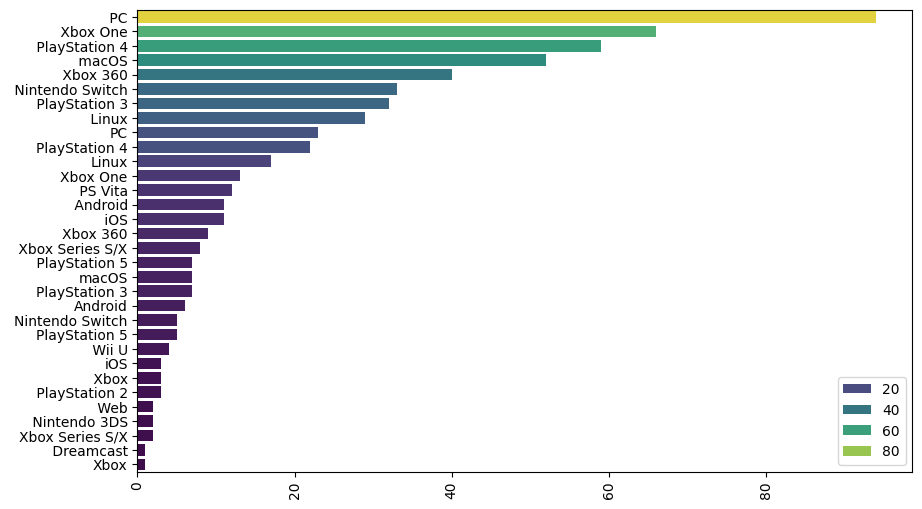

In [97]:
# Bar chart to sort which platform appears in more games
plt.figure(figsize=(10, 6))
sns.barplot(x=all_platforms.values(), y=all_platforms.keys(), hue=all_platforms.values(), palette="viridis")
plt.xticks(rotation=90)
plt.show()

In this chart we can see that PC appears in most of the games, appearing in a ratio of 78%, followed by Xbox One and Playstation 4

### Investigating `esrb_rating` column

In this case, I'm not dealing with NaN values yet, but the column `esrb_rating` have NaN values, because I don't want them to appear in my analysis I will simply not include them on my dictionary, and on my chart. The NaN values will be deal with on the next steps.

In [78]:
esrb_rating = {}
for rate in df_copy['esrb_rating']:
    if pd.notna(rate):
        if rate not in esrb_rating:
            esrb_rating[rate] = 1
        else:
            esrb_rating[rate] += 1
print(esrb_rating)

{'Mature': 75, 'Teen': 16, 'Everyone 10+': 6, 'Everyone': 3, 'Adults Only': 3, 'Rating Pending': 1}


<Axes: >

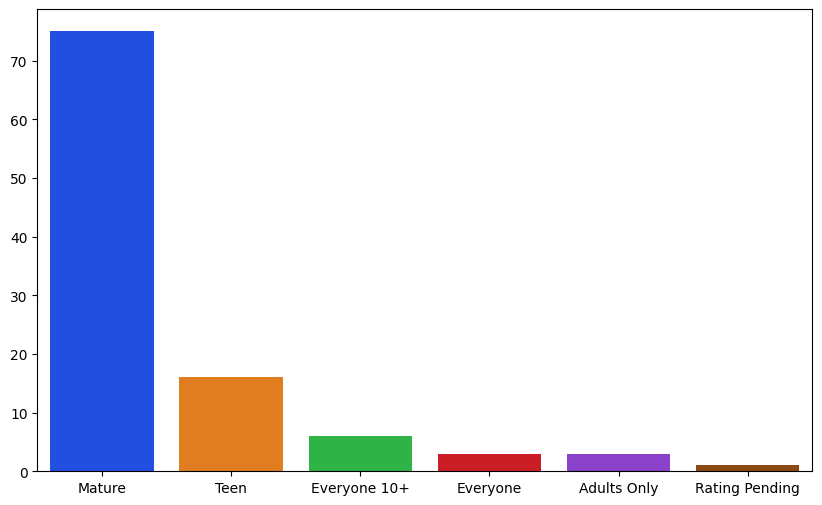

In [84]:
# Creating a barchart
plt.figure(figsize=(10, 6))
sns.barplot(x=esrb_rating.keys(), y=esrb_rating.values(), hue=esrb_rating.keys(), palette="bright")

### Investigating `tags` column

In [139]:
tags = {}
for tags_list in df['tags']:
    for tag in tags_list.split(","):
        if tag not in tags:
            tags[tag] = 1
        else:
            tags[tag] += 1

print(tags)

{'Singleplayer': 106, ' Steam Achievements': 65, ' Full controller support': 64, ' Steam Cloud': 53, ' Atmospheric': 95, ' steam-trading-cards': 49, ' Great Soundtrack': 63, ' RPG': 49, ' Story Rich': 67, ' Open World': 53, ' Third Person': 50, ' Fantasy': 19, ' Gore': 22, ' Violent': 14, ' Stealth': 28, ' Action RPG': 25, ' Anime': 3, ' Hack and Slash': 12, ' War': 8, ' In-App Purchases': 9, ' Dark Fantasy': 13, ' Medieval': 6, ' Magic': 9, ' Multiplayer': 56, ' Co-op': 39, ' First-Person': 54, ' Partial Controller Support': 33, ' FPS': 49, ' Online Co-Op': 28, ' Exploration': 31, ' Sandbox': 31, ' Third-Person Shooter': 23, ' PvP': 13, ' Realistic': 5, ' Mature': 14, ' Cinematic': 20, ' Historical': 5, ' Crime': 11, ' Online PvP': 2, ' 3rd-Person Perspective': 14, ' Blood': 6, ' America': 5, ' Masterpiece': 5, ' Beautiful': 3, ' Hunting': 3, ' Western': 2, ' 3rd-person': 2, ' cooperative': 32, ' Sci-fi': 44, ' Free to Play': 12, ' Online multiplayer': 7, ' Action-Adventure': 21, ' Sp

In [170]:
top_20_tags = dict(
    sorted(
        tags.items(),
        key=lambda item: item[1],
        reverse=True
    )[:20]
)
print(top_20_tags)

{'Singleplayer': 106, ' Atmospheric': 95, ' Story Rich': 67, ' Steam Achievements': 65, ' Full controller support': 64, ' Great Soundtrack': 63, ' Multiplayer': 56, ' First-Person': 54, ' Steam Cloud': 53, ' Open World': 53, ' Third Person': 50, ' steam-trading-cards': 49, ' RPG': 49, ' FPS': 49, ' Sci-fi': 44, ' Co-op': 39, ' Partial Controller Support': 33, ' cooperative': 32, ' Horror': 32, ' Exploration': 31}


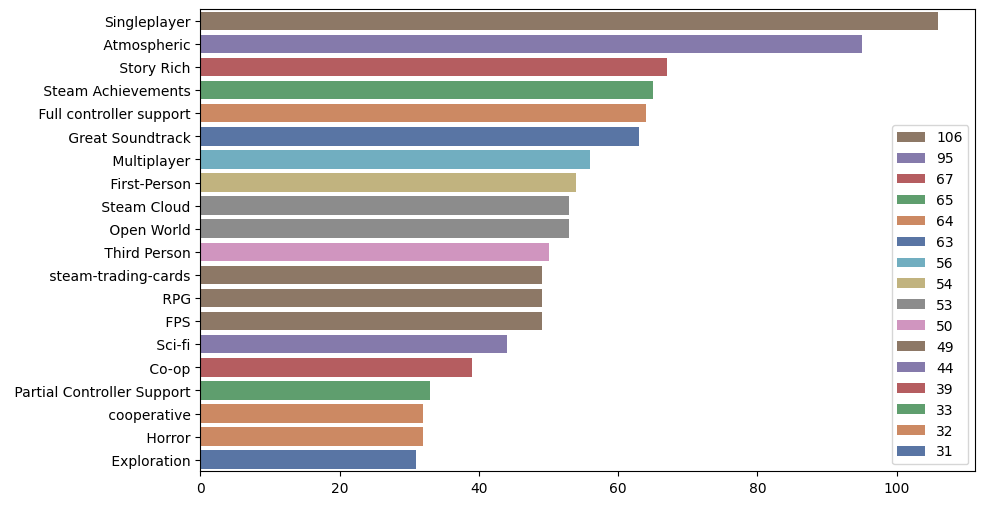

In [141]:
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x=top_20_tags.values(), y=top_20_tags.keys(), hue=top_20_tags.values(), palette="deep")
sns.move_legend(barplot, loc='lower right', reverse=True)
plt.show()

### Investigating `released` column

What I'm thinking is to create a chart that shows how many games were released by year, and I want to create a time series chart that shows how many games were released on each month in each year

In [167]:
# First I will create a pie chart to visualize the released games per year
years = df_copy['released']
total_year_occurrencies = {}
for year in years:
    released_year = year.year
    if released_year not in total_year_occurrencies:
        total_year_occurrencies[released_year] = 1
    else:
        total_year_occurrencies[released_year] += 1
print(total_year_occurrencies)

{2017: 11, 2018: 5, 2015: 14, 2004: 5, 2011: 6, 2002: 1, 2016: 14, 2013: 11, 2012: 11, 2010: 10, 2014: 7, 2007: 5, 2008: 5, 2009: 3, 2006: 2, 1998: 1, 2005: 1, 2000: 1, 2020: 3, 2019: 4}


In [168]:
total_year_occurrencies = dict(
    sorted(total_year_occurrencies.items())
)
print(total_year_occurrencies)

{1998: 1, 2000: 1, 2002: 1, 2004: 5, 2005: 1, 2006: 2, 2007: 5, 2008: 5, 2009: 3, 2010: 10, 2011: 6, 2012: 11, 2013: 11, 2014: 7, 2015: 14, 2016: 14, 2017: 11, 2018: 5, 2019: 4, 2020: 3}


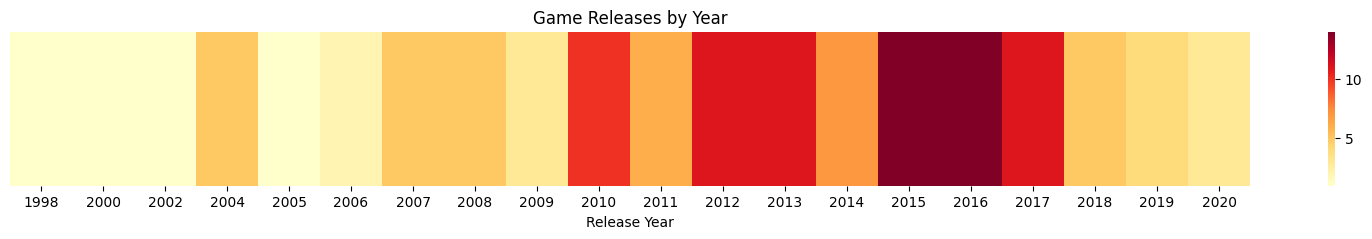

In [169]:
year_heatmap = pd.DataFrame(
    [list(total_year_occurrencies.values())],
    columns=total_year_occurrencies.keys()
)

plt.figure(figsize=(20, 2))

sns.heatmap(
    year_heatmap,
    annot=False,
    fmt='d',
    cmap='YlOrRd',
    cbar=True
)

plt.title('Game Releases by Year')
plt.xlabel('Release Year')
plt.yticks([])

plt.show()

In [186]:
# After checking my heatmap, I tought of creating time series charts for the top 3 most released years
top_3_years = dict(
    sorted(
        total_year_occurrencies.items(),
        key=lambda item: item[1],
        reverse=True
    )[:3]
)
print(top_3_years.keys())

dict_keys([2015, 2016, 2012])


In [193]:
# Here I created a variable to save my released columns on a datetime format, 
# that way I can easily manipulate to retrieve information by year
top_3_released_years_in_datetime = pd.to_datetime(df_copy["released"], errors="coerce")
top_3_released_years_in_datetime

0     2017-09-27
1     2018-10-26
2     2017-09-06
3     2017-05-05
4     2017-04-27
         ...    
115   2019-08-27
116   2019-11-15
117   2020-09-17
118   2019-02-04
119   2020-08-04
Name: released, Length: 120, dtype: datetime64[s]

## Bivariate Analysis

## Dealing With Missing Values 

## Correlation Analysis